In [68]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as st
import seaborn as sn
import math as mt
from skimage.io import imread, imsave
from matplotlib import pyplot as plt
np.random.seed(52)

Момент, плотность, распределение

In [69]:
def MuK(k, _ord_X):
    return np.sum([(x_i - np.mean(_ord_X))**k for x_i in _ord_X]) / len(_ord_X)

def p(x):
    return np.where(x >= 0, np.exp(-x), 0)

def F(x):
    return np.where(x >= 0, 1 - np.exp(-x), 0)

Генерация выборки

In [70]:
n = 25

#Равномерное распределение на отрезке от 0 до 1
U = np.random.uniform(0, 1, size = n)

#Решаем обратное уравнение для функции распределения и находим X
X = -np.log(1-U)

#Сортируем наши случайные величины
ord_X = np.sort(X)


a. Мода, Медиана, размах выборки, оценка коэффициента ассиметрии.

In [71]:
#Размах выборки

data_range = np.ptp(ord_X)
print(f"Размах выборки: {data_range}")

#Медиана

median = ord_X.mean()
print(f"Медиана: {median}")

#Мода 
def mode(_ord_X):
    values, counts = np.unique(_ord_X, return_counts=True)
    max_count = counts.max()

    if max_count == 1:
        return None

    mode_value = values[counts.argmax()]
    return mode_value

mode = mode(ord_X)
if mode is not None:
    print(f"Мода: {mode}")
else: 
    print("Мода: все значения разные")

#оценка коэффициента ассиметрии
def skewness(_ord_X):
    return (MuK(3, _ord_X) / MuK(2, _ord_X)**1.5)
print(f"Коэффициент ассиметрии: {skewness(ord_X)}")





Размах выборки: 3.90726040768725
Медиана: 1.0994380273935962
Мода: все значения разные
Коэффициент ассиметрии: 1.3132086484418037


b. Эмпирическая функция распределения, гисторграмма, boxplot

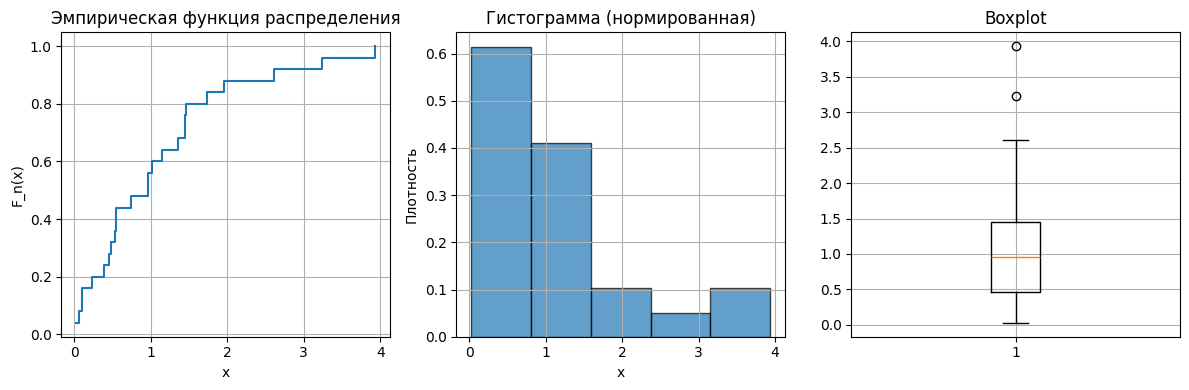

Q1 = 0.4595870171378784
Q2 (медиана) = 0.9634393885971513
Q3 = 1.4479795472573795
IQR = 0.9883925301195011
Нижняя граница для выбросов = -1.0230017780413732
Верхняя граница для выбросов = 2.930568342436631
Выбросы: [3.23536243 3.93372552]


In [72]:
# Эмпирическая функция распределения, гистограмма и boxplot

# Эмпирическая функция распределения (ступенчатый график)
F_n = np.arange(1, n + 1) / n

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.step(ord_X, F_n, where="post", label="Эмпирическая F_n(x)")
plt.xlabel("x")
plt.ylabel("F_n(x)")
plt.title("Эмпирическая функция распределения")
plt.grid(True)

# Гистограмма с равными интервалами и нормировкой по длине интервала
k = int(1 + np.log2(n))  # число интервалов (округление вниз)

sample_range = data_range
bin_width = sample_range / k

bins = np.linspace(ord_X.min(), ord_X.max(), k + 1)

# plt.hist с density=True уже делит на (n * ширину), т.е. даёт плотность
plt.subplot(1, 3, 2)
plt.hist(ord_X, bins=bins, density=True, edgecolor="black", alpha=0.7)
plt.xlabel("x")
plt.ylabel("Плотность")
plt.title("Гистограмма (нормированная)")
plt.grid(True)

# Boxplot с вычислением квартилей и межквартильного размаха
Q1 = np.percentile(ord_X, 25)
Q2 = np.percentile(ord_X, 50)
Q3 = np.percentile(ord_X, 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ord_X[(ord_X < lower_bound) | (ord_X > upper_bound)]

plt.subplot(1, 3, 3)
plt.boxplot(ord_X, vert=True, showfliers=True)
plt.title("Boxplot")
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Q1 = {Q1}")
print(f"Q2 (медиана) = {Q2}")
print(f"Q3 = {Q3}")
print(f"IQR = {IQR}")
print(f"Нижняя граница для выбросов = {lower_bound}")
print(f"Верхняя граница для выбросов = {upper_bound}")

if len(outliers) == 0:
    print("Выбросов нет")
else:
    print("Выбросы:", outliers)


с. Сравнение плотности распределения среднего арифметического элементов выборки(ЦПТ) с bootstrap оценкой этой величины

![альтернативный текст](t2.c.jpg)

In [73]:


# Функция для генерации бутстрап-распределения статистики
def bootstrap_estimator(data, statistic_func, n_bootstrap=1000):
    n = len(data)
    # Генерируем N псевдовыборок и применяем к каждой statistic_func
    boot_samples = [np.random.choice(data, size=n, replace=True) for _ in range(n_bootstrap)]
    results = [statistic_func(sample) for sample in boot_samples]
    return np.array(results)

def boot_means(data, n_bootstrap=1000):
    return bootstrap_estimator(data, np.mean, n_bootstrap)

def boot_skews(data, n_bootstrap=1000):
    return bootstrap_estimator(data, st.skew, n_bootstrap)

def boot_medians(data, n_bootstrap=1000):
    return bootstrap_estimator(data, np.median, n_bootstrap)

def get_median_rank(n):
    return n // 2 + 1

# Плотность порядковой статистик
def pdf_order_stat(x, n, k, pdf_orig, cdf_orig):
    C = mt.factorial(n) / (mt.factorial(k-1) * mt.factorial(n-k))
    return pdf_orig(x) * C * ( (1 - cdf_orig(x))**(n-k) ) * ( cdf_orig(x)**(k-1) )

# Плотность нормального распределения
def normal_pdf(x, mu, sigma2):
    return (1 / np.sqrt(2 * np.pi * sigma2)) * np.exp( -0.5 * ((x - mu)**2 / sigma2) )

<Axes: >

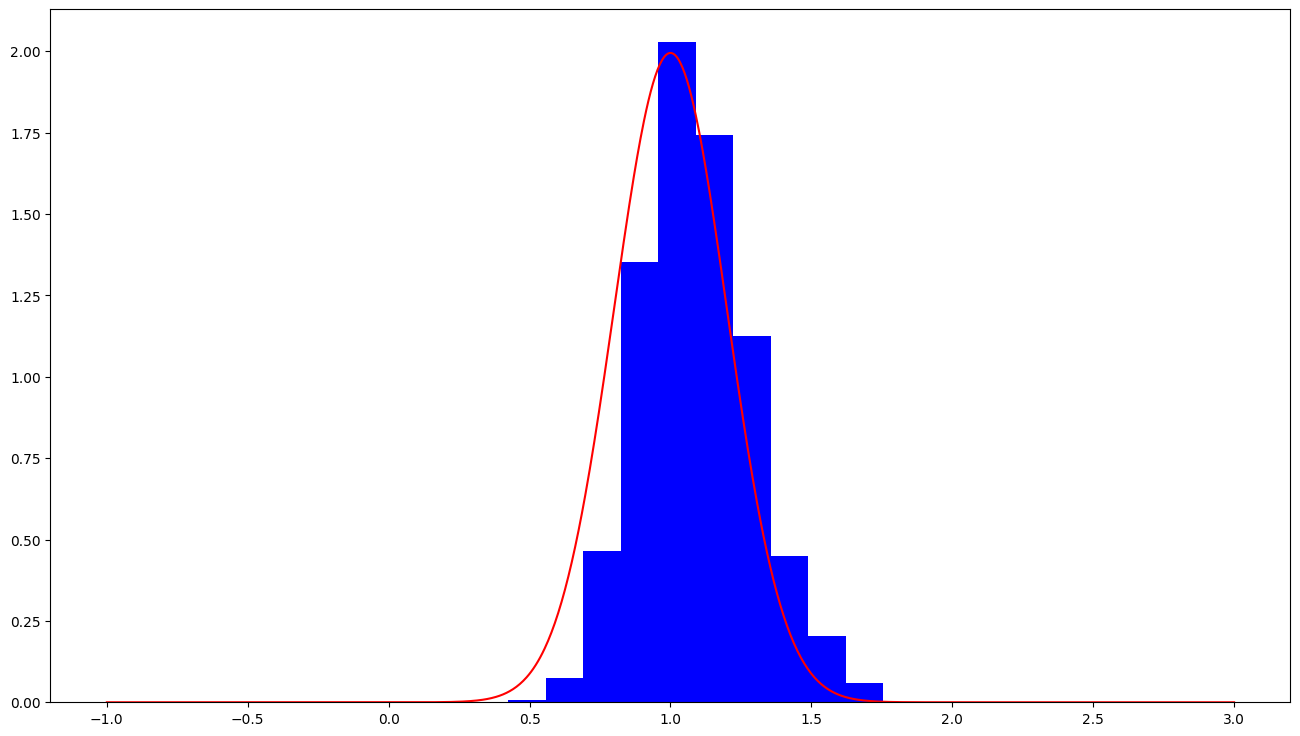

In [74]:
N = 1000
m_ksi = 1
D_ksi = 1/25

fig, axs = plt.subplots(1, 1, figsize = (16,9))
bt = boot_means(X, 1000)
axs.hist(bt, bins = int(np.log2(N)) + 1, color = 'blue', density=True)
x = np.linspace(-1, 3, 1000)
norm_x = normal_pdf(x, m_ksi, D_ksi)
axs.plot(x, norm_x, color = 'red')
axs

d. bootstrap оценка плотности распределния коэффициентов ассиметрии и оценка вероятности: коэф. ассиметрии < 1

Вероятность: 0.343


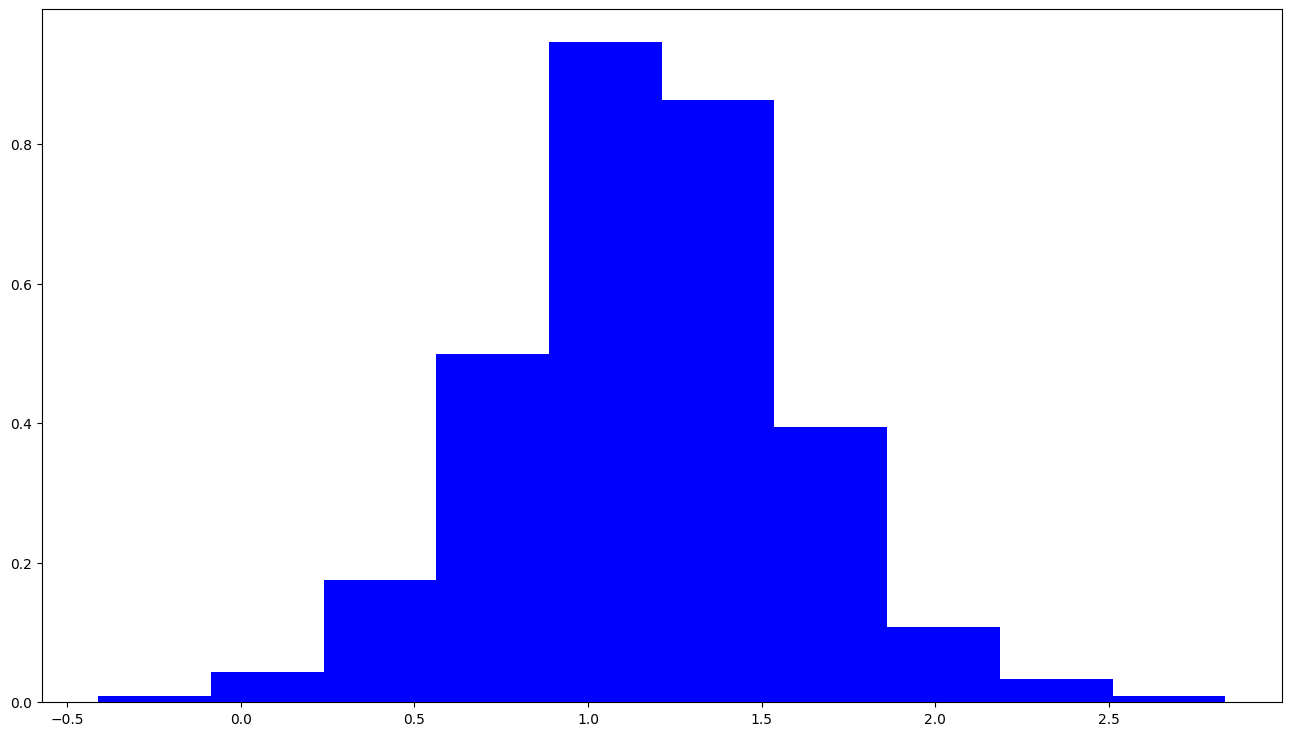

In [75]:
fig, axs = plt.subplots(1, 1, figsize = (16,9))
bt = boot_skews(X, N)
axs.hist(bt, bins = int(np.log2(N) + 1), color = 'blue', density = True)



chance_of_assym = np.count_nonzero(bt < 1) / N
print(f"Вероятность: {float(chance_of_assym)}")

e. Сравнение плотонсти распрделения медианы выборки с bootstrap оценкой этой величины

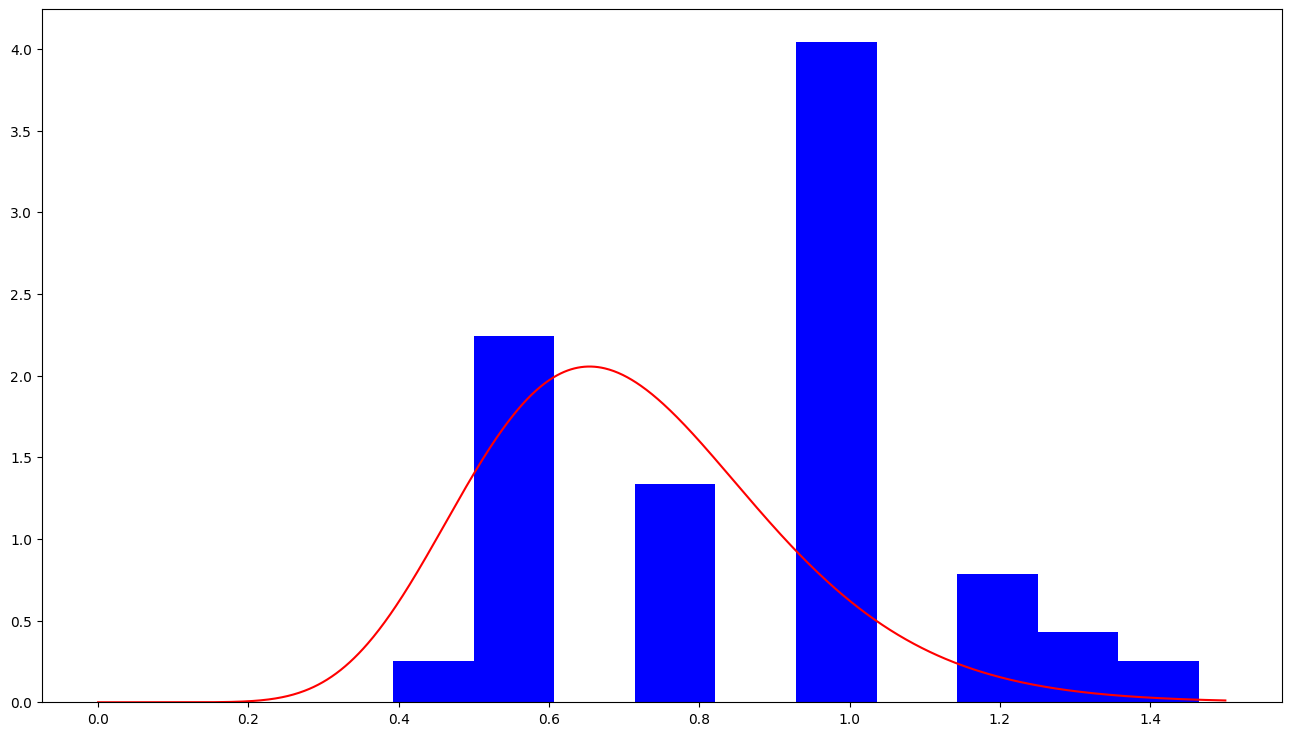

In [78]:
fig, axs = plt.subplots(1,1,figsize=(16,9))
bt = boot_medians(X, N)
axs.hist(bt, bins = int(np.log2(N))+1, color='blue', density=True)
x = np.linspace(0, 1.5, 1000)
y = [pdf_order_stat(x[i], 25, 13, p, F) for i in range(len(x))]
axs.plot(x,y,color='red')